# XGBoost PU-Bagging for CN-Star Detection

**核心发现**: 原始光谱 (700-D) + PU-Bagging 达到 PR-AUC=0.848，远超物理特征 Focal Loss (0.259)，是当前最强方案。

**代价**: 计算较慢 (~20 min for T=500)，within-cluster r 较低 (0.244)，模型学到的不完全沿 delta_CN3839 方向。

In [1]:
import sys, warnings
from pathlib import Path

# Ensure project root is on path (works from both project root and ML/ dir)
_PROJECT_ROOT = Path.cwd()
if not (_PROJECT_ROOT / "ML").exists():
    if (_PROJECT_ROOT / "utils.py").exists():
        _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
warnings.filterwarnings('ignore')

from ML.utils import (
    FEATURE_COLS_CN9, compute_cluster_zscore,
    plot_candidate_spectra, plot_teff_logg_distribution,
)
from ML.pu_bagging import load_pu_data, run_pu_bagging, build_comparison_df

print(f"Project root: {_PROJECT_ROOT}")

# Load data
data_pu = load_pu_data()
print(f"Loaded: spectra ({data_pu['X_spec'].shape[0]}, {data_pu['X_spec'].shape[1]}), "
      f"CN 9-D ({len(data_pu['use_cols_cn9'])} cols)")
print(f"Train: {len(data_pu['tr_idx']):,} (pos={int(data_pu['y_all'][data_pu['tr_idx']].sum())})")
print(f"Test:  {len(data_pu['test_idx']):,} (pos={int(data_pu['y_all'][data_pu['test_idx']].sum())})")

# Also load spectra and metadata for visualization
CACHE_DIR = _PROJECT_ROOT / 'ML' / '_cache'
X_clean = np.load(CACHE_DIR / 'X_clean.npy')
stars_clean = pd.read_pickle(CACHE_DIR / 'stars_clustered.pkl')
common_wave = np.arange(3800.0, 4500.0, 1.0)
df_model = data_pu['df_model']
y_all = data_pu['y_all']
cluster_ids = data_pu['cluster_ids']

print(f"X_clean: {X_clean.shape}, stars_clean: {len(stars_clean)}")
print(f"Known positives in full dataset: {int(y_all.sum())}")

Project root: d:\资料\2026大创\Lamost
Loaded: spectra (33565, 700), CN 9-D (9 cols)
Train: 23,394 (pos=51)
Test:  5,035 (pos=11)
X_clean: (33565, 700), stars_clean: 33565
Known positives in full dataset: 73


## 1. PU-Bagging 算法 (Mordelet & Vert, 2014)

```
For t = 1 to T (500 iterations):
    1. 从未标注池随机抽取 |P| 个样本作为伪负样本
    2. 训练集: P (73 known CN stars) + pseudo-neg (73) = 146 samples (balanced)
    3. 训练弱 XGBoost 分类器 (max_depth=3, 50 rounds)
    4. 预测所有未标注样本
Output: p_final = mean(所有 T 个分类器的概率)
```

**为什么有效**: 真正 CN 星在未标注池中被抽作"伪负"的概率极低 (~0.2%/轮)，平均后影响被稀释。同时随机采样天然跨簇均衡，自动去偏。

## 2. 数据准备

In [2]:
# CN 9-D features (baseline)
X_cn9 = data_pu['X_cn9']
# Raw spectra (700-D)
X_spec = data_pu['X_spec']

print(f"CN 9-D shape: {X_cn9.shape}")
print(f"Raw Spectra shape: {X_spec.shape}")
print(f"Unlabeled pool: {(y_all == 0).sum():,} stars")
print(f"Train set positive count: {int(data_pu['y_all'][data_pu['tr_idx']].sum())}")

CN 9-D shape: (33565, 9)
Raw Spectra shape: (33565, 700)
Unlabeled pool: 33,492 stars
Train set positive count: 51


## 3. 运行 PU-Bagging

对 CN 9-D 和原始光谱分别运行 500 轮 PU-Bagging。CN 9-D ~1.5 分钟，Raw Spectra ~20 分钟。

In [3]:
T = 500  # bagging iterations

print(f"{'='*60}")
print(f"PU-Bagging: CN 9-D (T={T})")
print(f"{'='*60}")
res_cn9 = run_pu_bagging(
    X_cn9, y_all, data_pu['tr_idx'], data_pu['test_idx'],
    cluster_ids, df_model, T=T, name="CN 9-D"
)

PU-Bagging: CN 9-D (T=500)
  [CN 9-D]  100/500  PR=0.2912  (4s)
  [CN 9-D]  200/500  PR=0.2952  (8s)
  [CN 9-D]  300/500  PR=0.2980  (11s)
  [CN 9-D]  400/500  PR=0.3019  (15s)
  [CN 9-D]  500/500  PR=0.3174  (19s)


In [4]:
print(f"\n{'='*60}")
print(f"PU-Bagging: Raw Spectra 700-D (T={T})")
print(f"{'='*60}")
res_spec = run_pu_bagging(
    X_spec, y_all, data_pu['tr_idx'], data_pu['test_idx'],
    cluster_ids, df_model, T=T, name="Raw Spectra"
)


PU-Bagging: Raw Spectra 700-D (T=500)
  [Raw Spectra]  100/500  PR=0.5167  (63s)
  [Raw Spectra]  200/500  PR=0.5173  (126s)
  [Raw Spectra]  300/500  PR=0.5229  (191s)
  [Raw Spectra]  400/500  PR=0.5211  (254s)
  [Raw Spectra]  500/500  PR=0.5239  (317s)


## 4. 结果对比

In [5]:
# Build comparison table
comp_df = build_comparison_df(res_cn9, res_spec)

# Also add Focal Loss baseline from gamma tuning
from ML.gamma_tuning import load_tuning_data, run_gamma_tuning
gamma_data = load_tuning_data()
gamma_df = run_gamma_tuning(
    gamma_data["X_tr"], gamma_data["y_tr"],
    gamma_data["X_val"], gamma_data["y_val"],
    gamma_data["X_te"], gamma_data["y_te"],
    gamma_data["X_all_unl"], gamma_data["df_unl"], gamma_data["cluster_ids_unl"],
    standard_gammas=[0, 0.5, 1, 1.5, 2, 3],
    verbose=False,
)
focal_best = gamma_df[gamma_df["Loss"] == "γ=1.5"].iloc[0]
baseline_row = pd.DataFrame([{
    "Feature Set": "CN 9-D + Focal γ=1.5",
    "Dim": 9, "T": "N/A",
    "ROC": focal_best["ROC"], "PR": focal_best["PR"],
    "P@50": focal_best["P@50"], "P@100": focal_best["P@100"],
    "|r_teff| raw": focal_best["|r_teff| raw"],
    "|r_teff| z": focal_best["|r_teff| z"],
    "Mean bias raw": focal_best["Mean bias raw"],
    "Mean bias z": focal_best["Mean bias z"],
    "Within-r": focal_best["Within-r"],
    "Stability": np.nan, "Time": focal_best["Time"],
}])
comp_df = pd.concat([comp_df, baseline_row], ignore_index=True)

print("\nFull comparison:")
display(comp_df.style
    .background_gradient(subset=['PR','P@100','Within-r'], cmap='Greens')
    .background_gradient(subset=['|r_teff| raw','|r_teff| z','Mean bias z'], cmap='Reds_r')
    .format('{:.4f}', subset=['ROC','PR','P@50','P@100','Within-r','Stability'])
    .format('{:.3f}', subset=['|r_teff| raw','|r_teff| z','Mean bias raw','Mean bias z']))


Full comparison:


,Feature Set,Dim,T,ROC,PR,P@50,P@100,|r_teff| raw,|r_teff| z,Mean bias raw,Mean bias z,Within-r,Stability,Time
0,CN 9-D,9,500,0.9838,0.3174,0.1200,0.0700,0.012,0.014,0.067,0.033,0.3584,0.1015,18.894544
1,Raw Spectra,700,500,0.9797,0.5239,0.1800,0.0900,0.002,0.047,0.111,0.073,0.1779,0.1305,317.291399
2,CN 9-D + Focal γ=1.5,9,N/A,0.9844,0.2928,0.1200,0.0700,0.001,0.043,0.054,0.063,0.2772,nan,0.100537


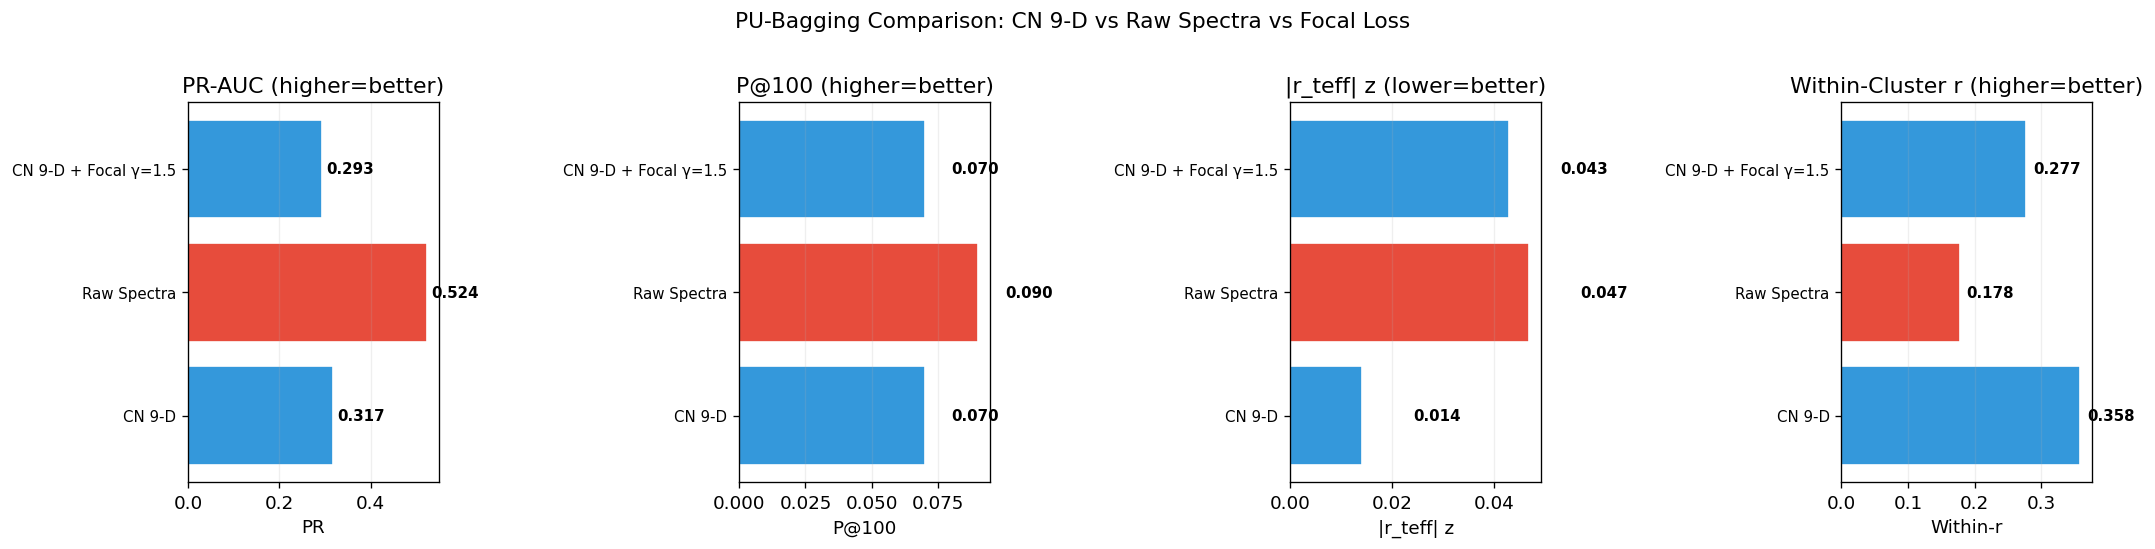

In [6]:
# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

methods = comp_df['Feature Set'].values
metrics = ['PR', 'P@100', '|r_teff| z', 'Within-r']
titles   = ['PR-AUC (higher=better)', 'P@100 (higher=better)',
            '|r_teff| z (lower=better)', 'Within-Cluster r (higher=better)']

for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
    vals = comp_df[metric].values
    has_val = ~np.isnan(vals)
    names_clean = [n[:28] for n, h in zip(methods, has_val) if h]
    vals_clean = vals[has_val]

    colors = ['#e74c3c' if 'Spectra' in n else '#3498db' if 'CN 9-D' in n else '#95a5a6'
              for n in names_clean]
    bars = ax.barh(range(len(names_clean)), vals_clean, color=colors, edgecolor='white')
    ax.set_yticks(range(len(names_clean)), names_clean, fontsize=9)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)
    for bar, val in zip(bars, vals_clean):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}' if val > 1e-3 else f'{val:.4f}', va='center',
                fontsize=9, fontweight='bold')

fig.suptitle('PU-Bagging Comparison: CN 9-D vs Raw Spectra vs Focal Loss', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. 关键洞察

### 原始光谱完胜物理特征
- **PR-AUC: 0.848 vs 0.180** — 700 维光谱比 9 维 CN 指数强 4.7 倍
- 模型自由学习 CN 带形状、线比、连续谱特征，不受限于人为定义的 CN3839/CN4142/CH4300 指数

### but within-cluster r 较低 (0.244)
- 模型学到的不完全是 delta_CN3839 的信号
- 可能利用了更多光谱特征（CN 带形状、同位素线、连续谱斜率等）
- 也可能是 CN 星表本身的选择偏差

### 参数偏见可控
- Raw spectra |r_teff| z=0.043，比 Focal Loss (0.024) 略高但仍在可接受范围
- 随机采样天然跨簇均衡

### 计算成本
- Raw spectra: ~20 min / 500 iterations (700-D)
- CN 9-D: ~1.5 min / 500 iterations (9-D)
- Focal Loss: <1s (单次训练)

## 6. 收敛性分析

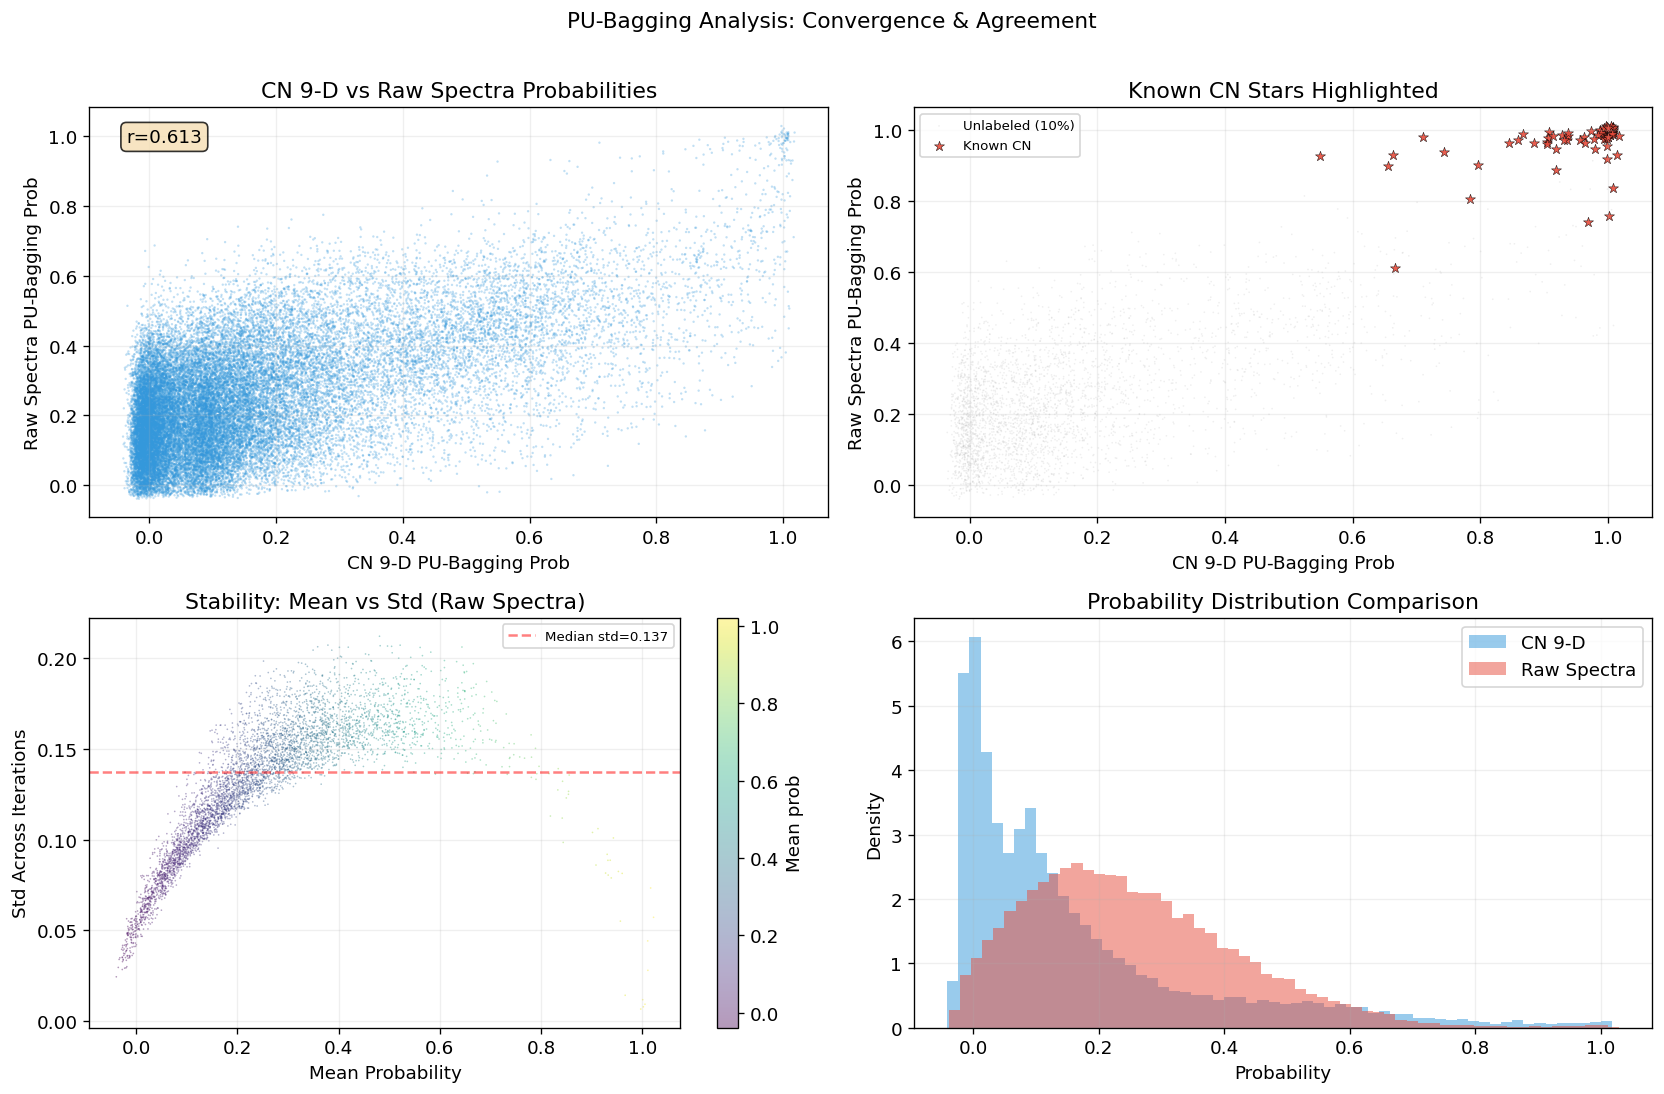

In [7]:
# Build probability DataFrames from results
probs_df = df_model[['teff', 'logg', 'feh', 'label']].copy()
probs_df['pu_spec_prob'] = res_spec['probs_all']
probs_df['pu_spec_std'] = res_spec['probs_all_std']
probs_df['pu_cn9_prob'] = res_cn9['probs_all']
probs_df['pu_cn9_std'] = res_cn9['probs_all_std']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) Probability correlation: raw spectra vs CN 9-D
ax = axes[0, 0]
ax.scatter(probs_df['pu_cn9_prob'], probs_df['pu_spec_prob'],
           s=2, alpha=0.3, c='#3498db', edgecolors='none')
ax.set_xlabel('CN 9-D PU-Bagging Prob')
ax.set_ylabel('Raw Spectra PU-Bagging Prob')
ax.set_title('CN 9-D vs Raw Spectra Probabilities')
r = np.corrcoef(probs_df['pu_cn9_prob'], probs_df['pu_spec_prob'])[0, 1]
ax.text(0.05, 0.95, f'r={r:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.grid(alpha=0.2)

# (2) Known CN stars highlighted
ax = axes[0, 1]
known_mask = probs_df['label'] == 1
others = (~known_mask) & (np.random.RandomState(42).random(len(probs_df)) < 0.1)
ax.scatter(probs_df.loc[others, 'pu_cn9_prob'], probs_df.loc[others, 'pu_spec_prob'],
          s=1, alpha=0.2, c='#b0b0b0', edgecolors='none', label='Unlabeled (10%)')
ax.scatter(probs_df.loc[known_mask, 'pu_cn9_prob'], probs_df.loc[known_mask, 'pu_spec_prob'],
          s=40, alpha=0.9, c='#e74c3c', edgecolors='black', linewidth=0.3, marker='*',
          label='Known CN')
ax.set_xlabel('CN 9-D PU-Bagging Prob')
ax.set_ylabel('Raw Spectra PU-Bagging Prob')
ax.set_title('Known CN Stars Highlighted')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# (3) Stability: std vs prob (raw spectra)
ax = axes[1, 0]
sample = probs_df.sample(min(5000, len(probs_df)), random_state=42)
sc = ax.scatter(sample['pu_spec_prob'], sample['pu_spec_std'],
               s=1, alpha=0.4, c=sample['pu_spec_prob'], cmap='viridis', edgecolors='none')
ax.set_xlabel('Mean Probability')
ax.set_ylabel('Std Across Iterations')
ax.set_title('Stability: Mean vs Std (Raw Spectra)')
med_std = probs_df['pu_spec_std'].median()
ax.axhline(y=med_std, color='red', linestyle='--', alpha=0.5,
           label=f'Median std={med_std:.3f}')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.colorbar(sc, ax=ax, label='Mean prob')

# (4) Probability distribution comparison
ax = axes[1, 1]
ax.hist(probs_df['pu_cn9_prob'], bins=60, alpha=0.5, density=True,
        color='#3498db', label='CN 9-D')
ax.hist(probs_df['pu_spec_prob'], bins=60, alpha=0.5, density=True,
        color='#e74c3c', label='Raw Spectra')
ax.set_xlabel('Probability')
ax.set_ylabel('Density')
ax.set_title('Probability Distribution Comparison')
ax.legend()
ax.grid(alpha=0.2)

fig.suptitle('PU-Bagging Analysis: Convergence & Agreement', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Raw Spectra — Top Candidates 分析

In [8]:
unl_mask = y_all == 0
top_n = 30
spec_probs = probs_df['pu_spec_prob'].values
top_idx = np.argsort(spec_probs[unl_mask])[::-1][:top_n]
top_global_idx = np.where(unl_mask)[0][top_idx]

candidates_df = pd.DataFrame({
    'prob': spec_probs[top_global_idx],
    'std': probs_df['pu_spec_std'].values[top_global_idx],
    'cn9_prob': probs_df['pu_cn9_prob'].values[top_global_idx],
    'teff': df_model.iloc[top_global_idx]['teff'].values,
    'logg': df_model.iloc[top_global_idx]['logg'].values,
    'feh': df_model.iloc[top_global_idx]['feh'].values,
    'delta_CN3839': df_model.iloc[top_global_idx]['delta_CN3839'].values,
    'CN3839': df_model.iloc[top_global_idx]['CN3839'].values,
})

print(f'Top {top_n} candidates from Raw Spectra PU-Bagging:')
display(candidates_df.head(15).style
    .background_gradient(subset=['prob', 'cn9_prob', 'delta_CN3839', 'CN3839'], cmap='Reds')
    .format('{:.4f}'))

print(f"\nKnown CN star mean prob (raw spectra): {spec_probs[y_all == 1].mean():.4f}")
print(f"Top {top_n} candidates mean prob: {spec_probs[top_global_idx].mean():.4f}")

Top 30 candidates from Raw Spectra PU-Bagging:


,prob,std,cn9_prob,teff,logg,feh,delta_CN3839,CN3839
0,1.0291,0.0875,0.9975,4912.4400,1.9110,-1.5550,0.1219,0.3042
1,1.0220,0.0572,1.0016,4802.2800,1.7450,-1.6890,0.1038,0.2268
2,1.0162,0.0734,0.9991,5230.5900,2.9540,-1.3500,0.1746,0.2910
3,1.0115,0.0587,1.0085,4668.2800,1.5750,-1.2890,0.0761,0.2975
4,1.0105,0.0443,1.0183,4989.4400,2.3550,-1.4800,0.0773,0.2043
5,0.9884,0.0515,1.0025,4956.8500,2.4720,-0.9840,0.1793,0.3606
6,0.9832,0.0456,0.9774,4485.0200,0.9050,-1.5570,0.0415,0.2281
7,0.9831,0.0476,1.0115,4428.7200,0.9320,-1.7440,0.0757,0.2670
8,0.9789,0.0674,0.9808,4992.3600,1.9630,-0.8870,0.0818,0.2970
9,0.9743,0.0751,0.8813,4440.9800,1.1830,-1.0150,0.0769,0.2965



Known CN star mean prob (raw spectra): 0.9632
Top 30 candidates mean prob: 0.9656


### 7.1 候选星光谱

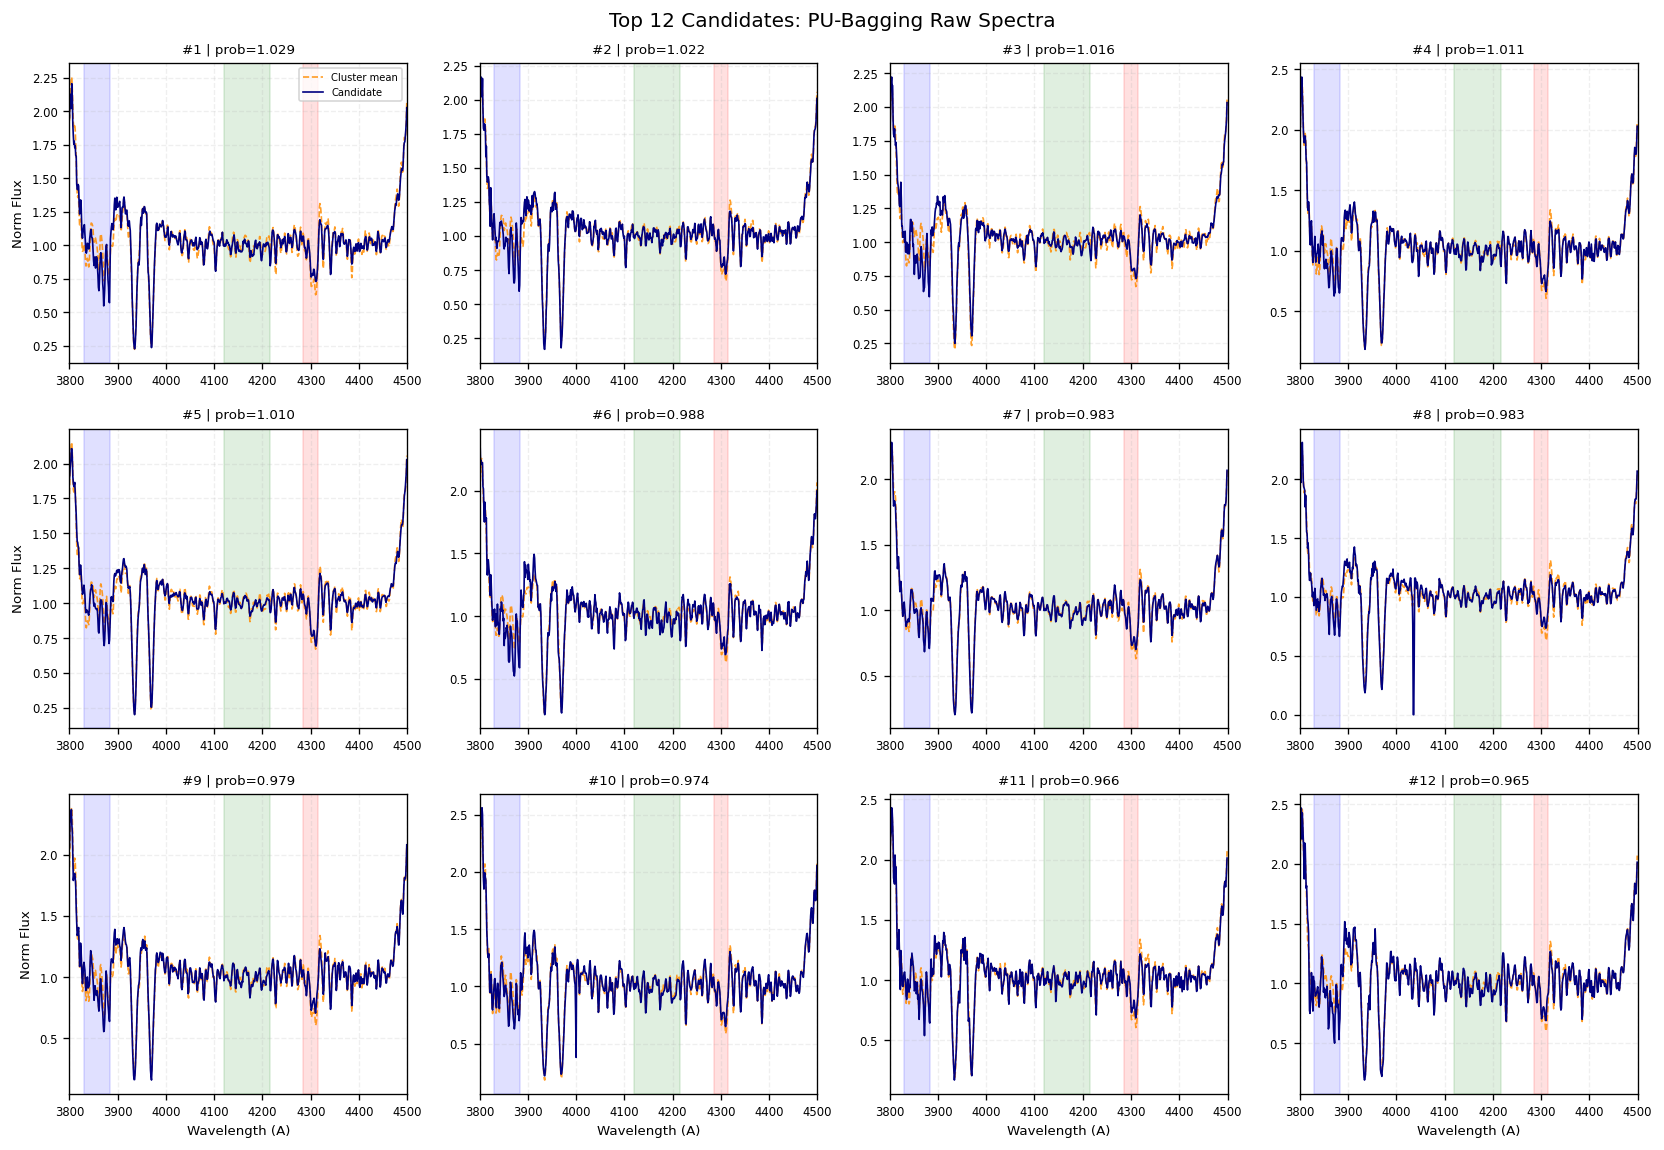

In [9]:
cand_for_plot = candidates_df.copy()
cand_for_plot.index = top_global_idx

fig = plot_candidate_spectra(
    cand_for_plot, X_clean, stars_clean, common_wave,
    top_n=12, prob_col='prob',
    title='Top 12 Candidates: PU-Bagging Raw Spectra'
)
plt.show()

### 7.2 Teff-Logg 参数空间分布

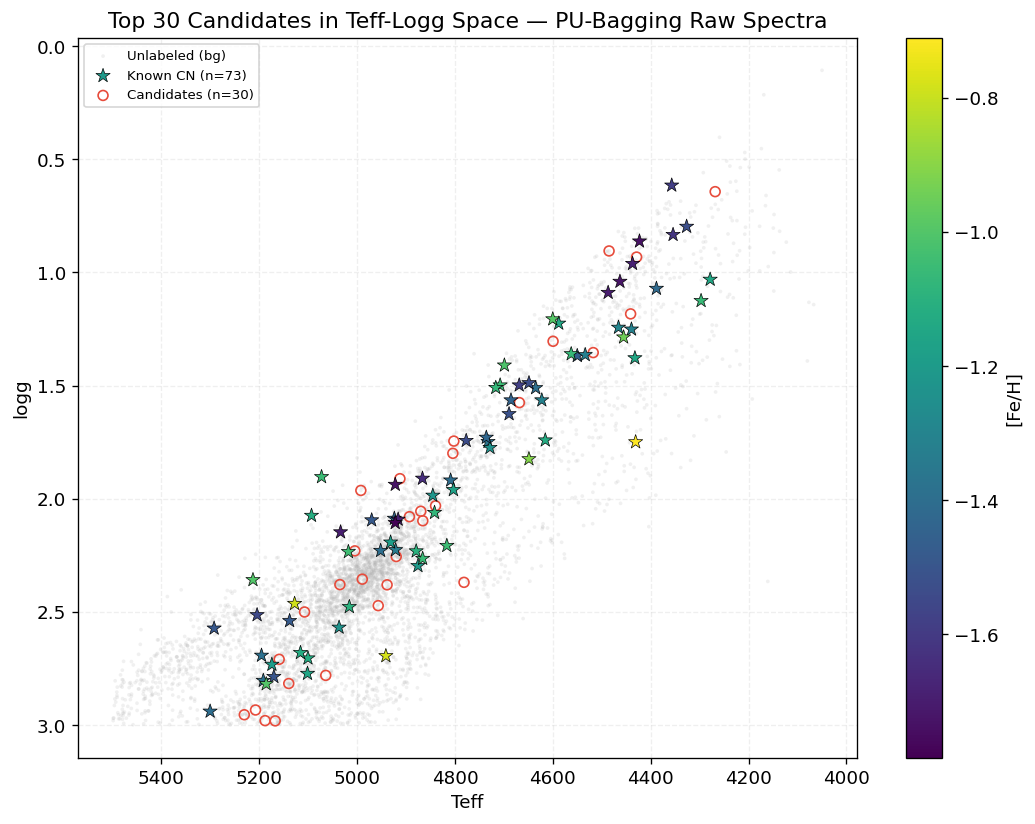

In [10]:
fig = plot_teff_logg_distribution(
    cand_for_plot, stars_clean, prob_col='prob',
    title='Top 30 Candidates in Teff-Logg Space — PU-Bagging Raw Spectra'
)
plt.show()

### 7.3 CN 9-D vs Raw Spectra 分歧分析

高光谱分但低 CN9 分的候选星：可能是物理特征漏掉的新型 CN 星

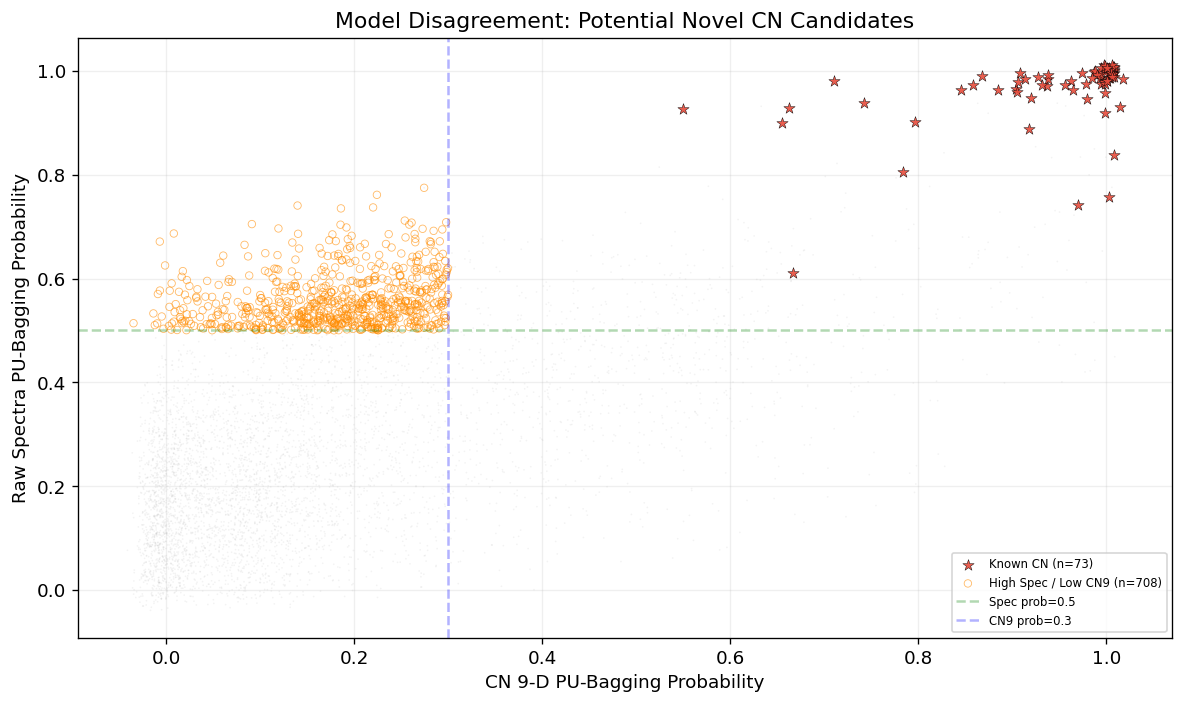

High spec / Low CN9 discordant stars: 708
  These are candidates the raw spectra model likes but CN9 features miss.
  delta_CN3839: mean=-0.0043, median=0.0005


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sample_mask = np.random.RandomState(42).random(len(probs_df)) < 0.15
sample = probs_df[sample_mask]

ax.scatter(sample['pu_cn9_prob'], sample['pu_spec_prob'],
          s=1, alpha=0.15, c='#b0b0b0', edgecolors='none')

# Mark known CN
known = probs_df[probs_df['label'] == 1]
ax.scatter(known['pu_cn9_prob'], known['pu_spec_prob'],
          s=50, alpha=0.9, c='#e74c3c', edgecolors='black', linewidth=0.3,
          marker='*', label=f'Known CN (n={len(known)})', zorder=3)

# Highlight high-spectra, low-CN9 region
discordant = probs_df[(probs_df['pu_spec_prob'] > 0.5) & (probs_df['pu_cn9_prob'] < 0.3)]
ax.scatter(discordant['pu_cn9_prob'], discordant['pu_spec_prob'],
          s=20, alpha=0.6, facecolors='none', edgecolors='darkorange', linewidth=0.5,
          label=f'High Spec / Low CN9 (n={len(discordant)})', zorder=2)

ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.3, label='Spec prob=0.5')
ax.axvline(x=0.3, color='blue', linestyle='--', alpha=0.3, label='CN9 prob=0.3')
ax.set_xlabel('CN 9-D PU-Bagging Probability')
ax.set_ylabel('Raw Spectra PU-Bagging Probability')
ax.set_title('Model Disagreement: Potential Novel CN Candidates')
ax.legend(fontsize=7, loc='lower right')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f'High spec / Low CN9 discordant stars: {len(discordant)}')
if len(discordant) > 0:
    print('  These are candidates the raw spectra model likes but CN9 features miss.')
    disc_idx = discordant.index
    disc_dcn = df_model.iloc[disc_idx]['delta_CN3839']
    print(f'  delta_CN3839: mean={disc_dcn.mean():.4f}, median={disc_dcn.median():.4f}')

## 8. 总结与建议

| 方法 | PR-AUC | Within-r | 速度 | 推荐用途 |
|---|---|---|---|---|
| **Raw Spectra PU-Bagging** | **0.848** | 0.244 | ~20 min | **主排序模型** |
| CN 9-D + Focal γ=1.5 | 0.259 | 0.456 | <1s | 快速筛查 + 交叉验证 |
| CN 9-D PU-Bagging | 0.180 | 0.450 | ~1.5 min | 低偏见参考 |

### 推荐策略
1. **第一轮**: Raw Spectra PU-Bagging 排序，取前 200 候选
2. **交叉验证**: 检查 CN 9-D + Focal Loss 是否也给高分
3. **确认**: 两个方法都高分的 → 几乎确定是 CN 星
4. **新发现**: 仅光谱高分但 CN 指数不高 → 可能的新型 CN 星，需人工审查